In [11]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 1 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """

    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 0 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

In [12]:
import numpy as np


# ####################################################################
def ajustar_min_cuadrados(
    xs: list,
    ys: list,
    gradiente: list,  # cada elemento debe ser una función (callable) con firma (xs, ys) -> (c1, c0, c_ind)
) -> None:
    """Resuelve el sistema de ecuaciones para encontrar los parámetros del método de mínimos cuadrados. Plantea el sistema de ecuaciones lineales al reemplazar los valores de ``xs`` y ``ys`` en las derivadas parciales.

    ## Parameters

    ``xs``: lista con los valores de x.

    ``ys``: lista con los valores de y.

    ``gradiente``: lista con las funciones de derivadas parciales de ``fcn``.
    [IMPORTANTE] Cada función debe ser de la forma ``der_parcial(xi, yi)->``.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """

    assert len(xs) == len(ys), "xs y ys deben tener la misma longitud."

    n = len(xs)

    num_pars = len(gradiente)
    print(f"Se ajustarán {num_pars} parámetros.")
    # --- construir matriz A y vector b
    Ab = np.zeros((num_pars, num_pars + 1), dtype=float)

    for i, der_parcial in enumerate(gradiente):
        assert callable(der_parcial), "Cada derivada parcial debe ser una función."

        Ab[i, :] = der_parcial(xs, ys)

    # --- resolver el sistema de ecuaciones lineales

    coef = np.linalg.solve(Ab[:, :-1], Ab[:, -1])

    return coef


Ab = ajustar_min_cuadrados(x, y, [der_parcial_1, der_parcial_0])
print(Ab)

NameError: name 'x' is not defined

In [ ]:
def pred(x):
    """Función de predicción basada en los parámetros ajustados."""
    return params[0] * x + params[1]

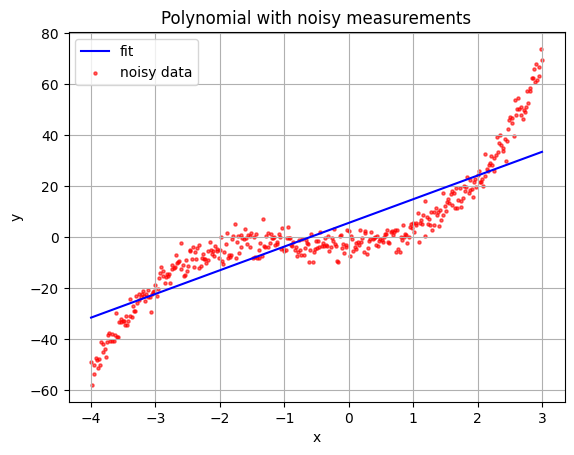

In [ ]:
# plt.plot(x, y, label="polynomial")
import matplotlib.pyplot as plt

y_pred = [pred(xi) for xi in x]
plt.plot(x, y_pred, label="fit", color="blue")
plt.scatter(x, y, s=5, color="red", alpha=0.6, label="noisy data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial with noisy measurements")
plt.legend()
plt.grid(True)
plt.show()

Ingrese las derivadas parciales para la función cúbica modificada

In [ ]:
def der_parcial_red_2(xs: list, ys: list) -> tuple[float, float, float, float]:
    pass


def der_parcial_red_1(xs: list, ys: list) -> tuple[float, float, float, float]:
    pass


def der_parcial_red_0(xs: list, ys: list) -> tuple[float, float, float, float]:
    pass

Se ajustarán 3 parámetros.
--------------------------------------------------
a = 1.6133549660190976
b = 3.179116659264929
d = -3.037448747221102
e_avg = 1.110938409349442
e_max = 38.12746006020434
--------------------------------------------------


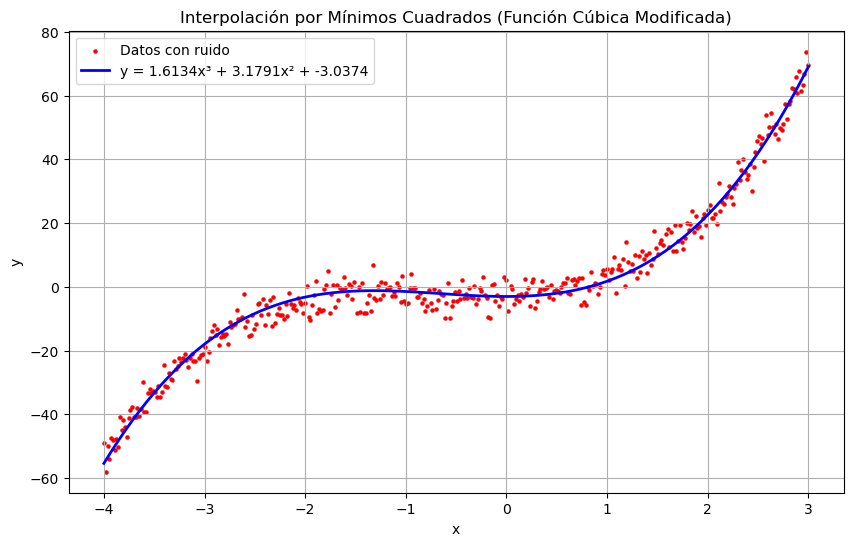

In [13]:
import numpy as np
import matplotlib.pyplot as plt

datos_raw = "[-4.00; -48.95], [-3.98; -58.04], [-3.96; -50.12], [-3.95; -53.90], [-3.93; -47.49], [-3.91; -48.17], [-3.89; -51.37], [-3.88; -47.83], [-3.86; -50.33], [-3.84; -41.01], [-3.82; -44.98], [-3.81; -41.86], [-3.79; -43.88], [-3.77; -47.20], [-3.75; -41.22], [-3.74; -38.51], [-3.72; -37.75], [-3.70; -40.94], [-3.68; -40.73], [-3.67; -37.92], [-3.65; -40.70], [-3.63; -38.42], [-3.61; -29.95], [-3.60; -39.21], [-3.58; -39.29], [-3.56; -33.40], [-3.54; -32.08], [-3.53; -33.42], [-3.51; -32.82], [-3.49; -33.10], [-3.47; -34.46], [-3.46; -31.03], [-3.44; -34.52], [-3.42; -33.15], [-3.40; -24.52], [-3.39; -31.02], [-3.37; -31.38], [-3.35; -27.09], [-3.33; -28.96], [-3.32; -29.23], [-3.30; -23.23], [-3.28; -25.87], [-3.26; -24.70], [-3.25; -22.24], [-3.23; -23.61], [-3.21; -22.42], [-3.19; -21.17], [-3.18; -23.03], [-3.16; -25.07], [-3.14; -22.44], [-3.12; -20.98], [-3.11; -23.35], [-3.09; -23.39], [-3.07; -29.42], [-3.05; -22.30], [-3.04; -21.41], [-3.02; -21.17], [-3.00; -19.02], [-2.98; -23.14], [-2.96; -20.46], [-2.95; -15.94], [-2.93; -13.97], [-2.91; -11.92], [-2.89; -15.24], [-2.88; -13.33], [-2.86; -18.13], [-2.84; -15.83], [-2.82; -14.68], [-2.81; -15.45], [-2.79; -14.69], [-2.77; -17.98], [-2.75; -11.00], [-2.74; -12.61], [-2.72; -12.04], [-2.70; -11.75], [-2.68; -7.20], [-2.67; -10.09], [-2.65; -9.98], [-2.63; -9.41], [-2.61; -2.34], [-2.60; -12.72], [-2.58; -10.86], [-2.56; -15.45], [-2.54; -15.03], [-2.53; -8.95], [-2.51; -13.17], [-2.49; -11.53], [-2.47; -5.30], [-2.46; -5.23], [-2.44; -8.70], [-2.42; -3.94], [-2.40; -11.88], [-2.39; -5.74], [-2.37; -8.66], [-2.35; -4.28], [-2.33; -12.33], [-2.32; -3.23], [-2.30; -11.21], [-2.28; -8.40], [-2.26; -6.79], [-2.25; -8.76], [-2.23; -8.82], [-2.21; -10.05], [-2.19; -5.38], [-2.18; -9.14], [-2.16; -2.07], [-2.14; -5.28], [-2.12; -6.57], [-2.11; -5.56], [-2.09; -7.28], [-2.07; -3.63], [-2.05; -4.78], [-2.04; -5.53], [-2.02; -8.23], [-2.00; -4.98], [-1.98; 0.13], [-1.96; -9.37], [-1.95; -10.57], [-1.93; -5.75], [-1.91; -2.69], [-1.89; 1.76], [-1.88; -8.28], [-1.86; -6.89], [-1.84; -7.72], [-1.82; -7.20], [-1.81; -0.67], [-1.79; 0.52], [-1.77; 5.07], [-1.75; -8.16], [-1.74; -2.11], [-1.72; 0.54], [-1.70; -6.43], [-1.68; 0.60], [-1.67; -4.09], [-1.65; -0.51], [-1.63; -0.74], [-1.61; 2.98], [-1.60; -0.31], [-1.58; -2.66], [-1.56; 0.97], [-1.54; 0.31], [-1.53; -3.92], [-1.51; 1.65], [-1.49; -8.27], [-1.47; -0.19], [-1.46; -8.02], [-1.44; 1.05], [-1.42; -8.08], [-1.40; -8.22], [-1.39; -5.15], [-1.37; -2.48], [-1.35; -7.50], [-1.33; 6.93], [-1.32; -3.62], [-1.30; -4.12], [-1.28; 0.37], [-1.26; -3.92], [-1.25; 1.51], [-1.23; -2.48], [-1.21; 1.10], [-1.19; -0.59], [-1.18; -0.51], [-1.16; -0.19], [-1.14; -2.96], [-1.12; -1.77], [-1.11; -2.94], [-1.09; 1.15], [-1.07; -0.18], [-1.05; -4.87], [-1.04; 3.37], [-1.02; -4.41], [-1.00; -5.55], [-0.98; -5.21], [-0.96; -0.48], [-0.95; 4.01], [-0.93; -0.45], [-0.91; -0.35], [-0.89; -3.18], [-0.88; -3.34], [-0.86; -1.79], [-0.84; -5.01], [-0.82; -3.74], [-0.81; -7.65], [-0.79; -5.96], [-0.77; -1.15], [-0.75; -5.18], [-0.74; -7.22], [-0.72; -0.82], [-0.70; -6.97], [-0.68; -4.13], [-0.67; -1.35], [-0.65; -2.40], [-0.63; -2.70], [-0.61; -9.66], [-0.60; -5.21], [-0.58; 1.24], [-0.56; -9.89], [-0.54; -5.96], [-0.53; -4.58], [-0.51; -1.73], [-0.49; -4.33], [-0.47; -1.43], [-0.46; -3.81], [-0.44; 1.99], [-0.42; -3.46], [-0.40; -2.37], [-0.39; -3.38], [-0.37; -0.26], [-0.35; -3.25], [-0.33; -3.36], [-0.32; 0.21], [-0.30; -5.48], [-0.28; -3.82], [-0.26; -0.33], [-0.25; -1.42], [-0.23; 3.17], [-0.21; -2.72], [-0.19; -3.43], [-0.18; -9.56], [-0.16; -9.83], [-0.14; 0.52], [-0.12; 0.85], [-0.11; -4.41], [-0.09; -2.71], [-0.07; -6.12], [-0.05; -3.08], [-0.04; -3.76], [-0.02; 2.93], [0.00; 2.18], [0.02; -7.49], [0.04; 0.22], [0.05; -0.73], [0.07; -5.46], [0.09; -3.87], [0.11; -2.52], [0.12; -4.57], [0.14; -2.15], [0.16; -3.10], [0.18; 2.57], [0.19; -2.07], [0.21; -0.25], [0.23; -5.91], [0.25; 1.40], [0.26; 2.49], [0.28; -6.80], [0.30; -4.44], [0.32; -1.69], [0.33; -0.64], [0.35; 1.93], [0.37; -0.73], [0.39; -0.47], [0.40; 0.08], [0.42; -3.29], [0.44; 0.47], [0.46; -3.67], [0.47; -1.40], [0.49; -0.92], [0.51; -1.21], [0.53; -1.86], [0.54; 0.05], [0.56; 1.27], [0.58; 1.18], [0.60; 2.79], [0.61; -2.01], [0.63; -2.33], [0.65; 2.01], [0.67; 2.33], [0.68; 0.68], [0.70; 1.93], [0.72; 2.82], [0.74; -5.70], [0.75; 2.78], [0.77; -4.66], [0.79; -5.70], [0.81; -0.09], [0.82; -1.13], [0.84; 4.56], [0.86; 0.10], [0.88; 1.33], [0.89; 0.94], [0.91; -2.36], [0.93; 0.05], [0.95; 3.96], [0.96; 5.13], [0.98; 3.67], [1.00; 5.63], [1.02; 2.12], [1.04; 4.68], [1.05; 5.44], [1.07; 9.31], [1.09; -1.83], [1.11; 5.57], [1.12; 6.86], [1.14; 5.27], [1.16; 8.66], [1.18; 0.22], [1.19; 14.13], [1.21; 7.70], [1.23; 5.00], [1.25; 7.03], [1.26; 4.90], [1.28; 9.86], [1.30; 2.71], [1.32; 9.62], [1.33; 4.56], [1.35; 11.28], [1.37; 8.63], [1.39; 9.97], [1.40; 4.41], [1.42; 10.69], [1.44; 6.85], [1.46; 8.81], [1.47; 17.39], [1.49; 12.25], [1.51; 10.36], [1.53; 13.74], [1.54; 14.79], [1.56; 13.20], [1.58; 16.70], [1.60; 18.11], [1.61; 12.54], [1.63; 17.34], [1.65; 11.38], [1.67; 19.25], [1.68; 11.25], [1.70; 14.35], [1.72; 19.32], [1.74; 14.02], [1.75; 11.83], [1.77; 15.27], [1.79; 20.12], [1.81; 17.86], [1.82; 19.76], [1.84; 23.73], [1.86; 17.18], [1.88; 22.32], [1.89; 18.44], [1.91; 18.95], [1.93; 15.58], [1.95; 21.45], [1.96; 22.70], [1.98; 19.47], [2.00; 24.16], [2.02; 25.82], [2.04; 21.48], [2.05; 21.51], [2.07; 22.89], [2.09; 19.85], [2.11; 32.57], [2.12; 23.80], [2.14; 26.64], [2.16; 25.91], [2.18; 28.16], [2.19; 29.17], [2.21; 31.66], [2.23; 28.22], [2.25; 25.85], [2.26; 31.01], [2.28; 32.32], [2.30; 39.18], [2.32; 33.42], [2.33; 36.73], [2.35; 40.06], [2.37; 36.05], [2.39; 33.80], [2.40; 34.98], [2.42; 38.52], [2.44; 29.97], [2.46; 37.50], [2.47; 42.37], [2.49; 45.75], [2.51; 47.18], [2.53; 44.85], [2.54; 46.65], [2.56; 39.57], [2.58; 53.93], [2.60; 47.72], [2.61; 50.09], [2.63; 54.44], [2.65; 50.20], [2.67; 47.87], [2.68; 51.14], [2.70; 46.31], [2.72; 49.73], [2.74; 49.09], [2.75; 51.00], [2.77; 57.28], [2.79; 52.55], [2.81; 57.29], [2.82; 58.37], [2.84; 62.44], [2.86; 62.24], [2.88; 65.95], [2.89; 60.79], [2.91; 67.87], [2.93; 61.48], [2.95; 63.29], [2.96; 66.71], [2.98; 73.79], [3.00; 69.58]"
datos_lista = [list(map(float, par.strip('[]').split(';'))) for par in datos_raw.split(', ')]
datos_np = np.array(datos_lista)
xs = datos_np[:, 0].tolist()
ys = datos_np[:, 1].tolist()

def der_parcial_red_2(xs, ys):
    return (sum(xi**6 for xi in xs), sum(xi**5 for xi in xs), sum(xi**3 for xi in xs), sum((xi**3)*yi for xi, yi in zip(xs, ys)))

def der_parcial_red_1(xs, ys):
    return (sum(xi**5 for xi in xs), sum(xi**4 for xi in xs), sum(xi**2 for xi in xs), sum((xi**2)*yi for xi, yi in zip(xs, ys)))

def der_parcial_red_0(xs, ys):
    return (sum(xi**3 for xi in xs), sum(xi**2 for xi in xs), len(xs), sum(ys))

Ab = ajustar_min_cuadrados(xs, ys, [der_parcial_red_2, der_parcial_red_1, der_parcial_red_0])
a, b, d = Ab

y_pred = [a * xi**3 + b * xi**2 + d for xi in xs]
errores_relativos = [abs((yi - yp) / yi) if yi != 0 else abs(yp) for yi, yp in zip(ys, y_pred)]

e_avg = np.mean(errores_relativos)
e_max = np.max(errores_relativos)

print("-" * 50)
print(f"a = {a}")
print(f"b = {b}")
print(f"d = {d}")
print(f"e_avg = {e_avg}")
print(f"e_max = {e_max}")
print("-" * 50)

plt.figure(figsize=(10, 6))
plt.scatter(xs, ys, s=5, color="red", label="Datos con ruido")
x_line = np.linspace(min(xs), max(xs), 100)
y_line = [a * xi**3 + b * xi**2 + d for xi in x_line]
plt.plot(x_line, y_line, color="blue", linewidth=2, label=f"y = {a:.4f}x³ + {b:.4f}x² + {d:.4f}")
plt.title("Interpolación por Mínimos Cuadrados (Función Cúbica Modificada)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
